# Machine learning: Reconnaissance de sorts (magiques)

## 1. Introduction

### a) Rappels

Ce notebook fait suite au TP Perceptron dans lequel nous avions construit un petit réseau de neurones - appelé perceptron - pour effectuer de la reconnaissance de caractères.


<img src="https://github.com/PlantecJY/python-mic/raw/master/principe.png" alt="Drawing" width="300" align="center"/>


Nous avions suivi les étapes ci-dessous :
* Structuration des données pour l’apprentissage (un dictionnaire de chiffres écrits représentés par des tableaux 5*6, comme dans l'exemple ci-dessous

```
nb9b = [[1,1,1,1,1],
        [1,0,0,0,1],
        [1,0,0,0,1],
        [1,1,1,1,1],
        [0,0,0,0,1],
        [1,1,1,1,1]]
```
* Création du réseau de neurones : une couche d'entrée de dimension 300 et une couche de sortie de dimension 10 ; l'information passée à chaque neurone de sortie était simplement la combinaison linéaire des neurones reliés à cette sortie pondérée par le poids de chaque neurone ;
* Test du fonctionnement du réseau de neurones ;
* Apprentissage, c'est-dire-optimisation du poids de chaque neurone ;
* Utilisation du réseau de neurones pour une faire une prédiction : on fournit un chiffre sous forme de tableau et on demande au réseau de prédire ce chiffre.

### b) Objectif de ce TP

Dans ce TP, l'objectif est de comprendre toute la chaîne d'apprentissage en Machine Learning à travers le domaine de la reconnaissance de gestes, et plus particulièrement de sorts (magiques). Nous allons donc passer par les étapes suivantes:
  1) Acquisition des données brutes et construction d'un dataset
  2) Split données d'entraînement/ données de test
  3) Pré-traitement des données (génération de features)
  4) Entraînement d'un modèle léger (réseau de neurones)
  5) Test du modèle
  6) Déploiement embarqué sur une carte 

## 2. Construction d'un dataset

Pour cette première étape, nous allons télécharger une base de données contenant déjà un certains nombre de gestes par label (qui sont au nombre de 3):
* 100 gestes du sort "Wingardium Leviosa"
* 100 gestes du sort "Stupefy"
* 100 gestes du sort "Expelliarmus"

Les gestes sont enregistrés, carte à la main, pendant une durée de 5 secondes, il est important de respecter ce temps d'acquisition pour l'enregistrement de nouvelles données.

L'objectif ici est de construire un tableau sur Python contenant les données que l'on pourra ensuite traîter pour entraîner/tester le modèle futur.


### a) Importation des bibliothèques nécessaires

In [103]:
!pip install pyserial
import zipfile
import os
import glob
import json
import pandas as pd
import os

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


### b) Upload du dataset

In [104]:
#Upload du fichier zip contenant les données brutes

zip_path = "reconnaissance-sort-export.zip" #Création d'une variable contenant le nom du fichier zip à ouvrir
data_sort = "edge_impulse_data" #Création d'une variable contenant le nom du fichier où on veut extraire le fichier zip

#Décompression du fichier zip vers la variable sort
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(data_sort)

#Que contient le fichier zip extrait
os.listdir(data_sort)

['info.labels', 'README.txt', 'testing', 'training']

### c) Rangement des données dans un tableau sur Python

Remarque: ici, les données sont dites "brutes", elles ne sont pas encore traitées pour entraîner et tester le modèle, on a ici les acquisitions temporelles de chaque enregistrements de gestes, ce qui donne beaucoup plus de lignes sur le tableau que de fichiers réels.

In [105]:
# Création d'un tableau pandas qui contient toutes les données

# Récupération de tous les fichiers JSON
files = glob.glob("edge_impulse_data/**/*.json", recursive=True)

dfs = []

for file in files:
    with open(file, "r", encoding="utf-8") as f:
        d = json.load(f)

    # Certains fichiers Edge Impulse ont les données dans "payload"
    payload = d["payload"] if "payload" in d else d

    # Récupération du nom des capteurs
    colonnes = [sensor["name"] for sensor in payload["sensors"]]

    # Transformation des mesures en tableau
    df = pd.DataFrame(payload["values"], columns=colonnes)

    # Chemin du fichier source
    df["source_file"] = file

    # Label = première partie du nom du fichier
    # Exemple : Expelliarmus.6r4pg4tp.ingestion-xxx.json -> Expelliarmus
    nom_fichier = os.path.splitext(os.path.basename(file))[0]
    df["label"] = nom_fichier.split(".")[0]

    # Données protégées : elles ne pourront pas être supprimées depuis le menu de nouvelles acquisitions de données
    df["origine"] = "edge_impulse"

    dfs.append(df)

# Fusion de tous les tableaux
data = pd.concat(dfs, ignore_index=True)

print("Nombre de fichiers JSON importés :", len(files))
print("Taille du dataset :", data.shape)

#Affichage des 5 premières lignes du tableau
data.head()


Nombre de fichiers JSON importés : 300
Taille du dataset : (75000, 9)


,AxX,AxY,AxZ,GxX,GxY,GxZ,source_file,label,origine
0,9.0544,-1.4692,3.4122,2.31,1.54,1.96,edge_impulse_data\testing\Expelliarmus.json.6s...,Expelliarmus,edge_impulse
1,9.0927,-1.7228,3.4696,0.49,1.05,2.59,edge_impulse_data\testing\Expelliarmus.json.6s...,Expelliarmus,edge_impulse
2,9.1071,-1.7228,3.4839,-0.98,0.35,4.06,edge_impulse_data\testing\Expelliarmus.json.6s...,Expelliarmus,edge_impulse
3,9.1406,-1.9813,3.4600,1.26,-0.21,3.50,edge_impulse_data\testing\Expelliarmus.json.6s...,Expelliarmus,edge_impulse
4,9.1310,-2.0100,3.3404,-0.56,0.07,2.38,edge_impulse_data\testing\Expelliarmus.json.6s...,Expelliarmus,edge_impulse


### d) Questions

1) Quelle est la fréquence d'enregistrement des données?
2) Que contient le fichier data_sort?
3) Quelle est la taille du dataset? Pourquoi est-il plus grand que le nombre d'enregistrements de base (300 au total)? Aidez vous de l'affichage des premières lignes du tableau.
4) Pourquoi est-il important de vérifier la qualité des données avant de commencer l'entraînement d'un modèle ?

## 3. Acquisition de nouvelles données

Dans cette section, il est possible d'enregistrer de nouvelles données pour compléter le dataset déjà existant ou ajouter un nouveau label et enregistrer ses données à l'aide de la carte Seeed Xiao NRF52840 sense.
Cela se fait à l'aide d'un menu interactif qui vous permettra d'avoir plusieurs options d'acquisition de données.

### a) Présentation de la carte Seeed Xiao NRF52840 sense

<img src="https://raw.githubusercontent.com/adarshbk12/Stage_IA/master/Seeed-Studio-XIAO-nRF52840-Sense.jpg" width="300">

La carte Seeed Xiao NRF52840 sense est équipée d'un IMU (Inertial Measurement Unit), qui renvoie les données d'un gyroscope (sur 3 axes) et d'un accéléromètre (sur 3 axes), cela nous permettra d'analyser les gestes réalisées.

Les étapes à suivre pour faire l'acquisition de nouvelles données sont:
* Brancher la carte sur un port USB
* Ajuster le numéro du port avec le "COMX", X le numéro du port.
* Lancer le menu d'acquisition

### a) Importation des bibliothèques nécessaires

In [106]:
import serial
import time
import pandas as pd
from datetime import datetime

### b) Les fonctions nécessaires au menu d'acquisition

In [107]:
# ============================================================
# 3 - Acquisition de nouvelles données avec Seeed XIAO nRF52840
# ============================================================

PORT = "COM10"          # À modifier selon ton ordinateur
BAUDRATE = 115200
DUREE_ACQUISITION = 5  # durée d'une acquisition en secondes

# On reprend les colonnes capteurs du dataset déjà chargé
colonnes_capteurs = [
    "AxX",
    "AxY",
    "AxZ",
    "GxX",
    "GxY",
    "GxZ"
]


#Fonction permettant de choisir le label sur lequel sera enregistré la nouvelle donnée
def choisir_label():
    labels = sorted(data["label"].unique())

    print("\n1 - Créer un nouveau label")
    print("2 - Utiliser un label existant")

    choix = input("Choix : ")

    if choix == "1":
        label = input("Nom du nouveau label : ").strip()
        return label

    elif choix == "2":
        print("\nLabels existants :")
        for i, label in enumerate(labels):
            print(f"{i + 1} - {label}")

        choix_label = int(input("Choisir un label : ")) - 1

        if 0 <= choix_label < len(labels):
            return labels[choix_label]
        else:
            print("Choix invalide.")
            return None

    else:
        print("Choix invalide.")
        return None


#Fonction permettant de lire le capteur de la Seeed Xiao
def lire_fenetre_xiao(label):
    global data

    donnees = []

    print(f"\nPrépare le geste pour le label : {label}")
    input("Appuie sur Entrée pour lancer l'acquisition...")

    ser = serial.Serial(PORT, BAUDRATE, timeout=1)
    time.sleep(3)  # laisse le temps à la XIAO de redémarrer

    ser.reset_input_buffer()
    ser.reset_output_buffer()

    # Envoie la commande de départ
    ser.write(b"S")
    ser.flush()

    print("Acquisition en cours...")

    debut = time.time()

    while True:
        ligne = ser.readline().decode("utf-8", errors="ignore").strip()

        if ligne == "":
            continue

        if ligne == "FIN":
            break

        try:
            valeurs = [float(x) for x in ligne.split(",")]

            if len(valeurs) == len(colonnes_capteurs):
                donnees.append(valeurs)
            else:
                print("Ligne ignorée, mauvais nombre de valeurs :", ligne)

        except:
            print("Ligne ignorée :", ligne)

    ser.close()

    if len(donnees) == 0:
        print("Aucune donnée reçue.")
        return None

    df_new = pd.DataFrame(donnees, columns=colonnes_capteurs)

    nom_acquisition = f"{label}_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
    df_new["source_file"] = nom_acquisition
    df_new["label"] = label
    df_new["origine"] = "xiao"

    data = pd.concat([data, df_new], ignore_index=True)

    print(f"Acquisition ajoutée : {nom_acquisition}")
    print(f"Nombre de lignes ajoutées : {len(df_new)}")

    return df_new

#Fonction permettant d'ajouter une nouvelle acquisition
def ajouter_une_acquisition():
    label = choisir_label()

    if label is None or label == "":
        print("Label invalide.")
        return

    df_new = lire_fenetre_xiao(label)

    if df_new is not None:
        display(df_new.head())


#Fonction permettant d'enchaîner 10 acquisitions à la suite
def faire_10_acquisitions():
    label = choisir_label()

    if label is None or label == "":
        print("Label invalide.")
        return

    for i in range(10):
        print(f"\n========== Acquisition {i + 1}/10 ==========")

        for sec in range(3, 0, -1):
            print(f"Début dans {sec}...")
            time.sleep(1)

        lire_fenetre_xiao(label)

    print(f"\n10 acquisitions terminées pour le label : {label}")

#Fonction permettant d'afficher la dernière acquisition
def afficher_derniere_acquisition():
    if len(data) == 0:
        print("Dataset vide.")
        return

    dernier_source = data["source_file"].iloc[-1]
    derniere = data[data["source_file"] == dernier_source]

    print("\nDernière acquisition")
    print("Label :", derniere["label"].iloc[0])
    print("Source :", dernier_source)
    print("Nombre de lignes :", len(derniere))

    display(derniere.head())

#Fonction permettant de supprimer la dernière acquisition
def supprimer_derniere_acquisition():
    global data

    acquisitions_xiao = data[data["origine"] == "xiao"]

    if len(acquisitions_xiao) == 0:
        print("Aucune acquisition XIAO à supprimer.")
        print("Les données Edge Impulse sont protégées.")
        return

    dernier_source = acquisitions_xiao["source_file"].iloc[-1]

    data = data[data["source_file"] != dernier_source].reset_index(drop=True)

    print("Dernière acquisition XIAO supprimée :", dernier_source)

#Fonction permettant de supprimer le dernier label créé avec ses données
def supprimer_dernier_label():
    global data

    acquisitions_xiao = data[data["origine"] == "xiao"]

    if len(acquisitions_xiao) == 0:
        print("Aucun label XIAO à supprimer.")
        print("Les labels Edge Impulse sont protégés.")
        return

    dernier_label = acquisitions_xiao["label"].iloc[-1]

    # Vérifie si le label existait déjà dans Edge Impulse
    label_protege = dernier_label in data[data["origine"] == "edge_impulse"]["label"].unique()

    if label_protege:
        print(f"Impossible de supprimer le label '{dernier_label}' car il existe dans Edge Impulse.")
        print("Seules les données XIAO ajoutées à ce label peuvent être supprimées.")
        return

    data = data[data["label"] != dernier_label].reset_index(drop=True)

    print("Label XIAO supprimé avec toutes ses données :", dernier_label)

#Fonction permettant d'afficher les labels
def afficher_labels():
    print("\nLabels existants :")
    print(data["label"].value_counts())


def menu_acquisition():
    while True:
        print("\n===== MENU ACQUISITION =====")
        print("1 - Ajouter une acquisition")
        print("2 - Faire 10 acquisitions à la suite")
        print("3 - Afficher la dernière acquisition")
        print("4 - Supprimer la dernière acquisition")
        print("5 - Supprimer le dernier label avec ses données")
        print("6 - Afficher les labels")
        print("7 - Quitter")

        choix = input("Choix : ")

        if choix == "1":
            ajouter_une_acquisition()

        elif choix == "2":
            faire_10_acquisitions()

        elif choix == "3":
            afficher_derniere_acquisition()

        elif choix == "4":
            supprimer_derniere_acquisition()

        elif choix == "5":
            supprimer_dernier_label()

        elif choix == "6":
            afficher_labels()

        elif choix == "7":
            print("Fin du menu.")
            break

        else:
            print("Choix invalide.")



### c) Acquisition

In [108]:
menu_acquisition()


===== MENU ACQUISITION =====
1 - Ajouter une acquisition
2 - Faire 10 acquisitions à la suite
3 - Afficher la dernière acquisition
4 - Supprimer la dernière acquisition
5 - Supprimer le dernier label avec ses données
6 - Afficher les labels
7 - Quitter


Choix :  7


Fin du menu.


### d) Questions

1) Refaire certaines fonctions et les compléter: par exemple afficher_labels
2) Combien de données faut-il au minimum pour un nouveau label selon vous pour se raccorder à la base de données initiale?
3) Quel est le risque d'avoir trop peu de données pour un label? A l'inverse quel est le risque qu'il y en ait trop?
4) Comment sont qualitativement la variance et le biais pour un cas d'overfitting? D'underfitting?
5) Quelles seraient les causes d'enregistrement de gestes trop différents pour un label?
6) Pourquoi un nombre équilibré d'exemples par classe est-il important ?
7) Que peut-il se produire si une classe est fortement sous-représentée ?
8) Pourquoi les labels doivent-ils être fiables ?

## 4. Split des données en training/test

Dans la deuxième étape de la chaîne d'apprentissage, on va séparer (split) les données en 2 catégories:
* Les données d'entraînement (training set) qui vont servir à entraîner le modèle, ces données seront elles-mêmes divisées en données d'entraînement et de validation du modèle
* Les données de test qui vont servir à tester le modèle une fois qu'il est entraîné

<img src="https://raw.githubusercontent.com/adarshbk12/Stage_IA/master/split.jpg" alt="Drawing" width="300" align="center"/>

### a) Importation des bibliothèques nécessaires

In [109]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import pandas as pd

### b) Réalisation du split

In [110]:
#Fonction qui réalise le split training/test

def split_dataset(data, test_size=0.2, random_state=42):
    """
    Sépare le dataset en ensembles d'entraînement et de test.

    Le découpage est effectué par acquisition (source_file) afin qu'une
    acquisition complète appartienne soit au jeu d'entraînement, soit au
    jeu de test. La proportion train/test est respectée pour chaque label.

    Paramètres
    ----------
    data : DataFrame
        Dataset complet.
    test_size : float
        Proportion des acquisitions à placer dans le jeu de test.
    random_state : int
        Graine aléatoire.

    Retour
    ------
    train_data, test_data
    """

    train_files = []
    test_files = []

    # Traitement indépendant pour chaque label
    for label in data["label"].unique():

        acquisitions = (
            data[data["label"] == label]["source_file"]
            .drop_duplicates()
            .tolist()
        )

        train, test = train_test_split(
            acquisitions,
            test_size=test_size,
            random_state=random_state,
            shuffle=True
        )

        train_files.extend(train)
        test_files.extend(test)

    # Construction des DataFrames
    train_data = data[data["source_file"].isin(train_files)].copy()
    test_data = data[data["source_file"].isin(test_files)].copy()

    train_data.reset_index(drop=True, inplace=True)
    test_data.reset_index(drop=True, inplace=True)

    print(f"Pourcentage de test demandé : {test_size*100:.0f}%")
    print(f"Nombre de lignes training : {len(train_data)}")
    print(f"Nombre de lignes testing : {len(test_data)}")
    print(f"Shape training : {train_data.shape}")
    print(f"Shape testing : {test_data.shape}")

    print("\nRépartition par label :")
    repartition = pd.DataFrame({
        "Training": train_data.groupby("label")["source_file"].nunique(),
        "Testing": test_data.groupby("label")["source_file"].nunique()
    }).fillna(0).astype(int)

    repartition["Total"] = repartition["Training"] + repartition["Testing"]
    repartition["% Test"] = (
        repartition["Testing"] / repartition["Total"] * 100
    ).round(1)

    display(repartition)

    return train_data, test_data

In [111]:
# Exemple : 25 % des données pour le test
train_data, test_data = split_dataset(data, test_size=0.25)

Pourcentage de test demandé : 25%
Nombre de lignes training : 56250
Nombre de lignes testing : 18750
Shape training : (56250, 9)
Shape testing : (18750, 9)

Répartition par label :


,Training,Testing,Total,% Test
label,,,,
Expelliarmus,75,25,100,25.0
Stupefy,75,25,100,25.0
Wingardium Leviosa,75,25,100,25.0


### c) Graphique de la répartition des données

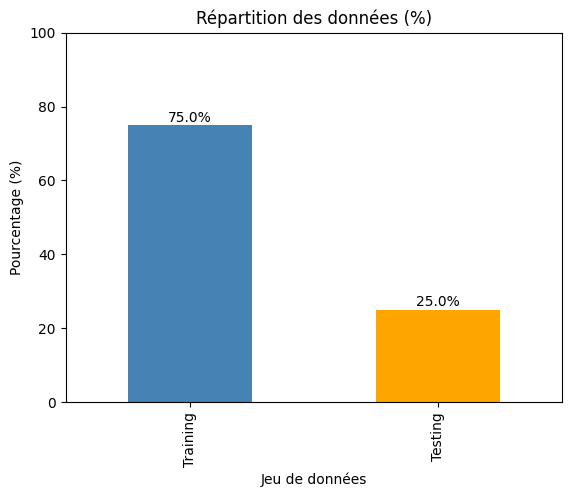

In [112]:
split_percent = pd.Series({
    "Training": len(train_data),
    "Testing": len(test_data)
})

# Conversion en pourcentages
split_percent = split_percent / split_percent.sum() * 100

ax = split_percent.plot(kind="bar", color=["steelblue", "orange"])

plt.title("Répartition des données (%)")
plt.xlabel("Jeu de données")
plt.ylabel("Pourcentage (%)")
plt.ylim(0, 100)

for i, v in enumerate(split_percent):
    ax.text(i, v + 1, f"{v:.1f}%", ha="center")

plt.show()

### d) Graphique de la répartition des données par LABEL

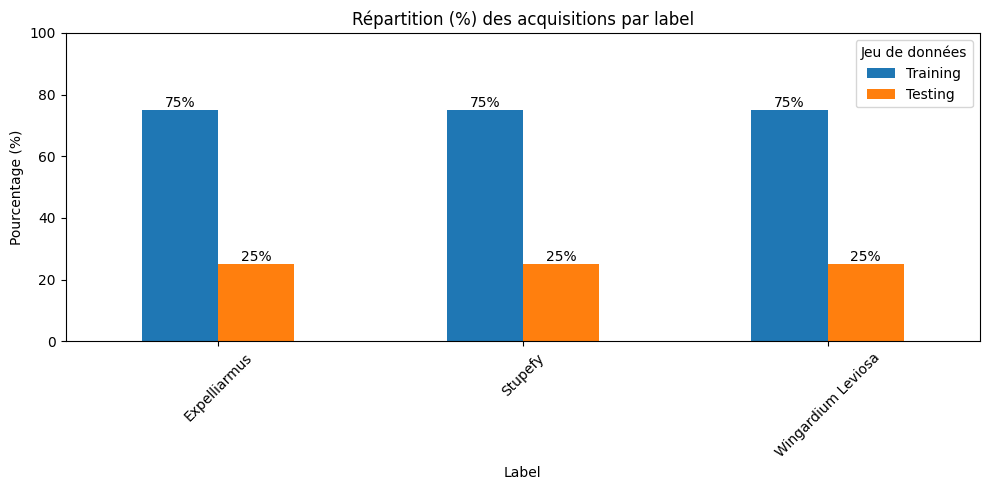

In [113]:
# Nombre d'acquisitions (source_file) par label dans chaque jeu

train_counts = (
    train_data.groupby("label")["source_file"]
    .nunique()
    .rename("Training")
)

test_counts = (
    test_data.groupby("label")["source_file"]
    .nunique()
    .rename("Testing")
)

# Fusion des résultats
label_split = pd.concat([train_counts, test_counts], axis=1).fillna(0)

# Conversion en pourcentage pour chaque label
label_split_percent = (
    label_split.div(label_split.sum(axis=1), axis=0) * 100
)

# Affichage
ax = label_split_percent.plot(kind="bar", figsize=(10, 5))

plt.title("Répartition (%) des acquisitions par label")
plt.xlabel("Label")
plt.ylabel("Pourcentage (%)")
plt.xticks(rotation=45)
plt.ylim(0, 100)

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f%%")

plt.legend(title="Jeu de données")
plt.tight_layout()
plt.show()

### e) Questions

1) Afficher la taille des données d'entraînement et de test et donner les valeurs
2) Afficher par graphique la répartition des données (par label aussi?)
3) Faire le split avec un pourcentage cohérent
4) Quel serait le risque d'avoir trop de données d'entraînement? Au contraire quel serait le risque qu'il y en ait pas assez?
5) Pourquoi est-il important d'avoir des données que le modèle n'a jamais vu? Quelles sont les performances que l'on peut observer du modèle grâce à elles?
6) Pourquoi ne faut-il jamais entraîner le modèle sur les données de test ?
7) Pourquoi mélange-t-on (shuffle) généralement les données avant le découpage ?
8) Quel risque prend-on si le jeu de test n'est pas représentatif du jeu d'entraînement ?
9) Que signifie le terme "généralisation" d'un modèle ?

## 5. Analyse spectrale

Dans cette section, nous allons réaliser l'analyse spectrale d'une donnée en particulier. Nous allons d'abord observer son image temporelle pour ensuite l'analyser grâce à une transformée de Fourier rapide (FFT). Cela nous permettra ensuite de générer des caractéristiques (features) pour toutes les données que l'on pourra utiliser pour entraîner et tester le modèle.


### a) Importation des bibliothèques nécessaires

In [114]:
import numpy as np
import matplotlib.pyplot as plt

### b) Image temporelle de la donnée brute

In [115]:
#Choix d'une fonction à analyser

def choisir_acquisition(dataset, label, numero):
    """
    Sélectionne une acquisition d'un label.

    Paramètres
    ----------
    dataset : train_data ou test_data
    label : nom du label
    numero : indice de l'acquisition (0 = première, 1 = deuxième, ...)
    """

    acquisitions = (
        dataset[dataset["label"] == label]["source_file"]
        .drop_duplicates()
        .tolist()
    )

    sample_file = acquisitions[numero]
    sample = dataset[dataset["source_file"] == sample_file]

    return sample


# Exemple
sample = choisir_acquisition(train_data, "Expelliarmus", 0)

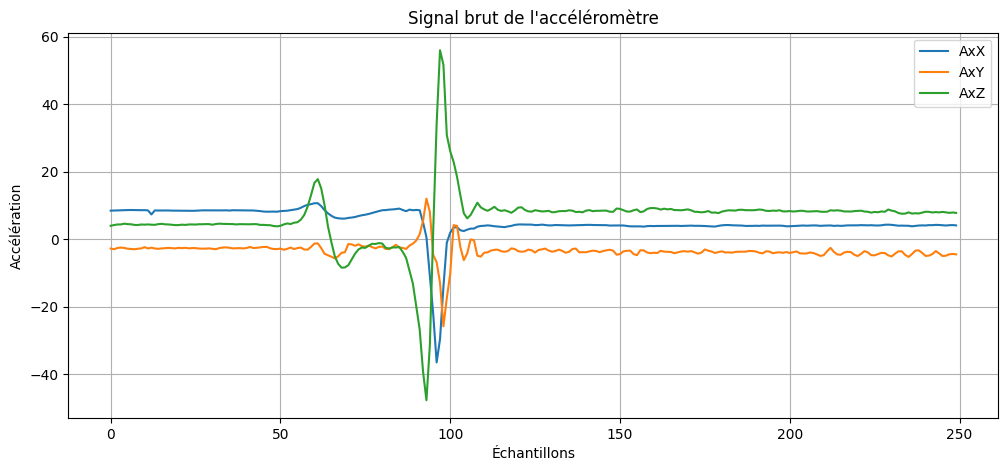

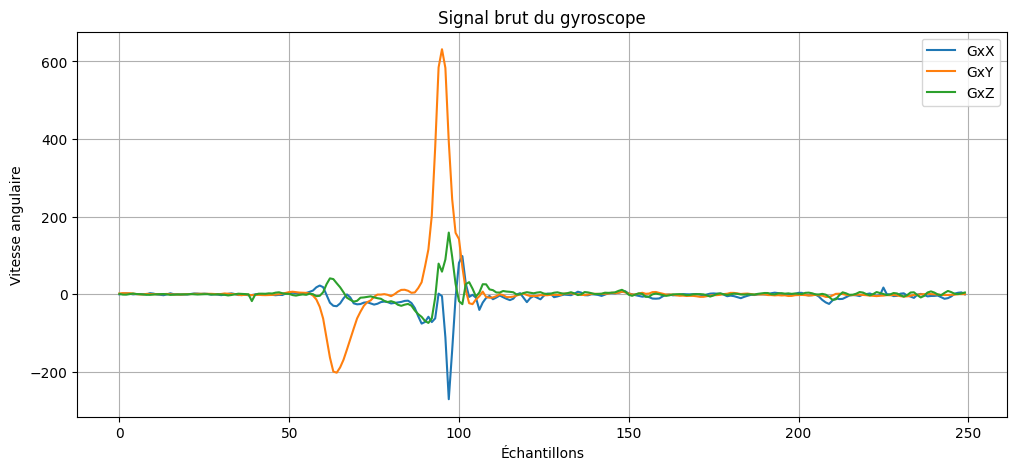

In [116]:
# Image en temporel de la donnée brute (accéléromètre)

plt.figure(figsize=(12, 5))

plt.plot(sample["AxX"], label="AxX")
plt.plot(sample["AxY"], label="AxY")
plt.plot(sample["AxZ"], label="AxZ")

plt.title("Signal brut de l'accéléromètre")
plt.xlabel("Échantillons")
plt.ylabel("Accélération")
plt.legend()
plt.grid(True)

plt.show()

# Image en temporel de la donnée brute (gyroscope)

plt.figure(figsize=(12, 5))

plt.plot(sample["GxX"], label="GxX")
plt.plot(sample["GxY"], label="GxY")
plt.plot(sample["GxZ"], label="GxZ")

plt.title("Signal brut du gyroscope")
plt.xlabel("Échantillons")
plt.ylabel("Vitesse angulaire")
plt.legend()
plt.grid(True)

plt.show()

### c) Analyse spectrale de la donnée

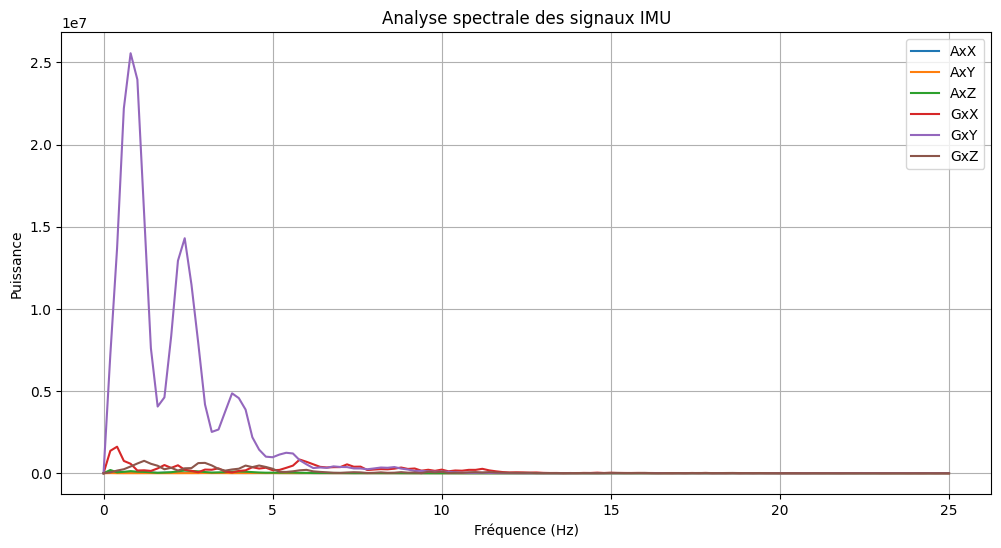

In [117]:
# Analyse spectrale (FFT)

# Fréquence d'échantillonnage
interval_ms = 20          # 20 ms si la XIAO échantillonne à 50 Hz (delay(20))
fs = 1000 / interval_ms

axes = ["AxX", "AxY", "AxZ", "GxX", "GxY", "GxZ"]

plt.figure(figsize=(12, 6))

# Application de la FFT sur chaque axe
for axis in axes:

    signal = sample[axis].values

    # Suppression de la composante continue
    signal = signal - np.mean(signal)

    fft_values = np.fft.rfft(signal)
    power = np.abs(fft_values) ** 2
    fft_freqs = np.fft.rfftfreq(len(signal), d=1/fs)

    plt.plot(fft_freqs, power, label=axis)

plt.title("Analyse spectrale des signaux IMU")
plt.xlabel("Fréquence (Hz)")
plt.ylabel("Puissance")
plt.legend()
plt.grid(True)

plt.show()

### d) Questions

1) Expliquez pourquoi il est préférable de faire une analyse fréquentielle plutot qu'une analyse temporelle dans ce cas de figure.
2) Quelle type de filtre appliqueriez vous en observant l'analyse spectrale des signaux IMU de chaque labels?
3) Determinez l'intervalle de temps pour avoir la bonne fréquence d'échantillonage correspondant à la carte Seeed Xiao NRF52840 sense.
4) Afficher l'analyse spectrale?
5) Expliquez qualitativement ce que fait la FFT sur le signal temporel et comment générer des caractéristiques par rapport au résultat obtenu.
6) Sur le sort "Expelliarmus" de numéro 0, quels sont les axes de l'IMU prédominants ? Comment vont-ils agir sur la génération des features?
7) Comment le bruit influence-t-il le spectre fréquentiel ?

## 6. Pré-traitement des données et génération de features

Ici, nous allons réaliser le pré-traitement des données avant l'entraînement du modèle:
* Nous allons d'abord réaliser un split des données d'entraînement en 2: celles qui vont servir à entraîner le modèle et celles qui vont servir à le valider
* Ensuite, nous allons réaliser l'analyse spectrale de toutes les données pour permettre la génération de caractéristiques (features) qui vont servir pour l'entraînement et le test.

### a) Importation des bibliothèques nécessaires

In [118]:
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
from scipy.stats import skew, kurtosis
from sklearn.preprocessing import StandardScaler, LabelEncoder

### b) Split train/validation

In [119]:
#Fonction qui réalise le split train/validation

def split_train_validation(train_data, validation_size=0.2, random_state=42):
    """
    Sépare le jeu d'entraînement en un jeu d'entraînement et un jeu de validation.

    Le découpage est effectué par acquisition (source_file) afin qu'une
    acquisition complète appartienne soit au jeu d'entraînement, soit au
    jeu de validation. La proportion est respectée pour chaque label.

    Paramètres
    ----------
    train_data : DataFrame
        Jeu d'entraînement.
    validation_size : float
        Proportion des acquisitions à placer dans le jeu de validation.
    random_state : int
        Graine aléatoire.

    Retour
    ------
    train_final, validation_data
    """

    train_files = []
    validation_files = []

    # Découpage indépendant pour chaque label
    for label in train_data["label"].unique():

        acquisitions = (
            train_data[train_data["label"] == label]["source_file"]
            .drop_duplicates()
            .tolist()
        )

        train, validation = train_test_split(
            acquisitions,
            test_size=validation_size,
            random_state=random_state,
            shuffle=True
        )

        train_files.extend(train)
        validation_files.extend(validation)

    train_final = train_data[
        train_data["source_file"].isin(train_files)
    ].reset_index(drop=True)

    validation_data = train_data[
        train_data["source_file"].isin(validation_files)
    ].reset_index(drop=True)

    print(f"Pourcentage de validation demandé : {validation_size*100:.0f}%")
    print(f"Nombre de lignes entraînement : {len(train_final)}")
    print(f"Nombre de lignes validation : {len(validation_data)}")

    print("\nRépartition par label :")
    repartition = pd.DataFrame({
        "Training": train_final.groupby("label")["source_file"].nunique(),
        "Validation": validation_data.groupby("label")["source_file"].nunique()
    }).fillna(0).astype(int)

    repartition["Total"] = (
        repartition["Training"] + repartition["Validation"]
    )

    repartition["% Validation"] = (
        repartition["Validation"] / repartition["Total"] * 100
    ).round(1)

    display(repartition)

    return train_final, validation_data

# Deuxième découpage : Train / Validation
train_data, validation_data = split_train_validation(
    train_data,
    validation_size=0.2
)

Pourcentage de validation demandé : 20%
Nombre de lignes entraînement : 45000
Nombre de lignes validation : 11250

Répartition par label :


,Training,Validation,Total,% Validation
label,,,,
Expelliarmus,60,15,75,20.0
Stupefy,60,15,75,20.0
Wingardium Leviosa,60,15,75,20.0


### c) Génération des caractéristiques pour toutes les données

In [120]:
# Axes du capteur
axes = ["AxX", "AxY", "AxZ", "GxX", "GxY", "GxZ"]


#Fonction qui génère les caractéristiques d'une donnée par analyse spectrale
def generate_spectral_features(sample, axes=axes, n_fft=20):
    """
    Génère les caractéristiques statistiques et fréquentielles
    d'une acquisition.

    Paramètres
    ----------
    sample : DataFrame
        Acquisition à analyser.
    axes : list
        Liste des axes IMU.
    n_fft : int
        Nombre de coefficients FFT conservés.

    Retour
    ------
    dict
        Dictionnaire contenant les caractéristiques.
    """

    features = {}

    for axis in axes:

        signal = sample[axis].to_numpy(dtype=float)

        # Suppression de la composante continue
        signal = signal - np.mean(signal)

        # Caractéristiques statistiques
        features[f"{axis}_rms"] = np.sqrt(np.mean(signal**2))
        features[f"{axis}_skewness"] = skew(signal)
        features[f"{axis}_kurtosis"] = kurtosis(signal)

        # FFT
        fft_values = np.fft.rfft(signal)
        power = np.abs(fft_values) ** 2

        # Conservation des n_fft premiers coefficients
        power = power[:n_fft]

        for i, value in enumerate(power):
            features[f"{axis}_fft_{i}"] = value

    return features

In [121]:
# 2. Fonction de génération des features pour toutes les données

def construire_features(dataset):
    feature_rows = []

    for source_file, sample in dataset.groupby("source_file"):
        features = generate_spectral_features(sample, axes, n_fft=20)

        features["source_file"] = source_file
        features["label"] = sample["label"].iloc[0]

        feature_rows.append(features)

    return pd.DataFrame(feature_rows)

In [122]:
# 3. Génération des features pour les trois jeux de données
features_train = construire_features(train_data)
features_validation = construire_features(validation_data)
features_test = construire_features(test_data)

#display(features_train.head())
#display(features_validation.head())
#display(features_test.head())

X_train = features_train.drop(columns=["source_file", "label"])
y_train = features_train["label"]

X_validation = features_validation.drop(columns=["source_file", "label"])
y_validation = features_validation["label"]

X_test = features_test.drop(columns=["source_file", "label"])
y_test = features_test["label"]

### d) Codage et normalisation des features

Ici, avant l'entraînement du modèle, il est important de coder et normaliser les caractéristiques pour permettre un entraînement optimal et efficace.

In [123]:
#Codage et normalisation des features

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_validation_encoded = label_encoder.transform(y_validation)
y_test_encoded = label_encoder.transform(y_test)

print(label_encoder.classes_)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_validation_scaled = scaler.transform(X_validation)
X_test_scaled = scaler.transform(X_test)

['Expelliarmus' 'Stupefy' 'Wingardium Leviosa']


### e) Questions

1) Quelle est la différence entre les données de test et les données de validation?
2) Faire le split train/validation 
3) Quelles sont les différentes méthodes de validation et comment fonctionnent-elles?
4) Pourquoi est-il important de pré-traiter les données avant l'entraînement?
5) Faire la fonction de génération de features pour toutes les données en utilisant la fonction generate_spectral_features
6) Pourquoi est-il important de normaliser les features?
7) Pourquoi faut-il coder les features avant l'entraînement?
8) Dans quels cas utiliseriez-vous une validation croisée (Cross Validation) ?
9) Quelle est la différence entre Hold-Out, K-Fold et Leave-One-Out ?
10) Quels sont les avantages et les inconvénients du K-Fold Cross Validation ?

## 7. Classification sur données d'entraînement

Nous passons maintenant à la partie de l'entraînement du modèle avec un réseau de neurones, grâce aux données d'entraînement. 

<img src="https://raw.githubusercontent.com/adarshbk12/Stage_IA/master/reseau_neurones.png"
     alt="Réseau de neurones"
     width="600">

Cela nous permettra ensuite d'observer les performances du modèle (métriques, matrice de confusion) avec les données de validation qui serviront à régler le modèle et l'ajuster.

### a) Importation des bibliothèques nécessaires

In [124]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import matplotlib.pyplot as plt

### b) Création du réseau de neurones et compilation du modèle

In [125]:
#Architecture du réseau de neurones

num_features = X_train_scaled.shape[1]
num_classes = len(label_encoder.classes_)

model = Sequential([
    Dense(64, activation="relu", input_shape=(num_features,)),
    Dropout(0.3),

    Dense(32, activation="relu"),
    Dropout(0.3),

    Dense(num_classes, activation="softmax")
])

C:\Program Files\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [126]:
#Compilation du modèle

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

### c) Entraînement du modèle

In [127]:
#Entraînement 

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled,
    y_train_encoded,
    validation_data=(X_validation_scaled, y_validation_encoded),
    epochs=20,
    batch_size=16,
    callbacks=[early_stop]
)

Epoch 1/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.6000 - loss: 0.9884 - val_accuracy: 0.9333 - val_loss: 0.4310
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8444 - loss: 0.3960 - val_accuracy: 1.0000 - val_loss: 0.1729
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9444 - loss: 0.2480 - val_accuracy: 1.0000 - val_loss: 0.0775
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9833 - loss: 0.1376 - val_accuracy: 1.0000 - val_loss: 0.0411
Epoch 5/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9944 - loss: 0.0878 - val_accuracy: 1.0000 - val_loss: 0.0245
Epoch 6/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9833 - loss: 0.0712 - val_accuracy: 1.0000 - val_loss: 0.0159
Epoch 7/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9889 - loss: 0.0498 - val_accuracy: 1.0000 - val_loss: 0.0109
Epoch 8/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 0.0398 - val_accuracy: 1.0000 - val_loss

### d) Performances de l'entraînement

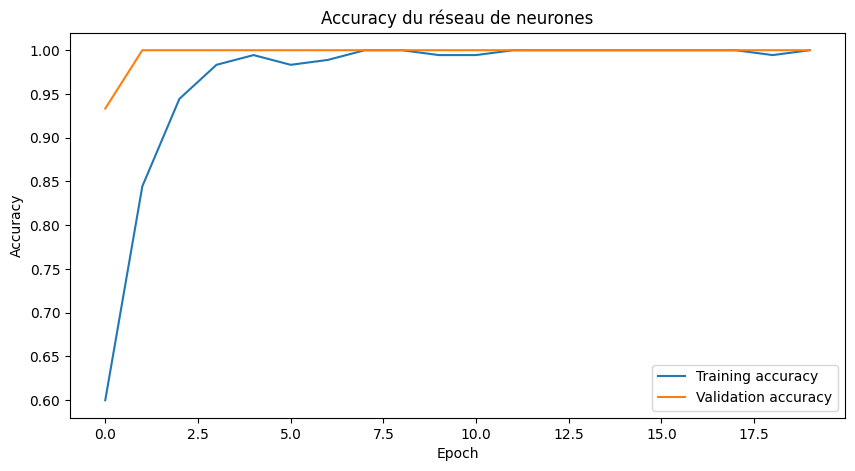

In [128]:
#Graphique de l'accuracy

plt.figure(figsize=(10, 5))

plt.plot(history.history["accuracy"], label="Training accuracy")
plt.plot(history.history["val_accuracy"], label="Validation accuracy")

plt.title("Accuracy du réseau de neurones")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

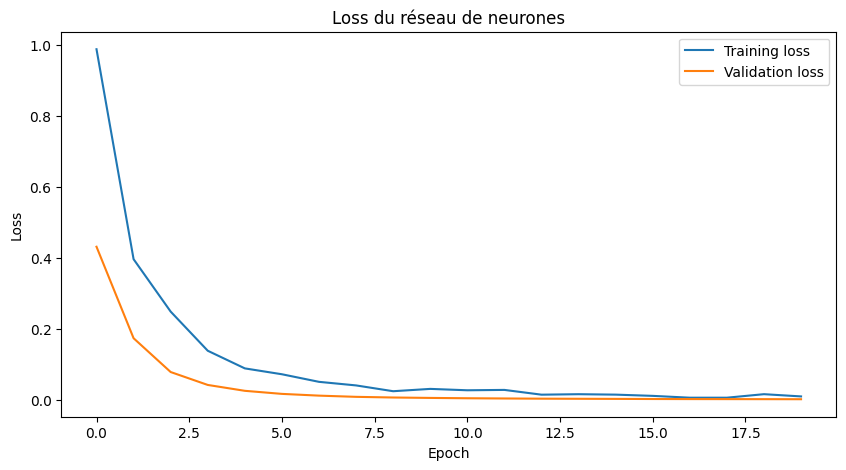

In [129]:
#Graphique de la fonction de perte du modèle

plt.figure(figsize=(10, 5))

plt.plot(history.history["loss"], label="Training loss")
plt.plot(history.history["val_loss"], label="Validation loss")

plt.title("Loss du réseau de neurones")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [130]:
#Métriques

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
import pandas as pd
import numpy as np

# Prédictions sur le jeu de validation
y_validation_proba = model.predict(X_validation_scaled)
y_validation_pred = np.argmax(y_validation_proba, axis=1)

# Calcul des métriques
metrics = pd.DataFrame({
    "Metric": [
        "Area under ROC Curve",
        "Weighted average Precision",
        "Weighted average Recall",
        "Weighted average F1 score"
    ],
    "Value": [
        roc_auc_score(
            y_validation_encoded,
            y_validation_proba,
            multi_class="ovr",
            average="weighted"
        ),
        precision_score(
            y_validation_encoded,
            y_validation_pred,
            average="weighted",
            zero_division=0
        ),
        recall_score(
            y_validation_encoded,
            y_validation_pred,
            average="weighted",
            zero_division=0
        ),
        f1_score(
            y_validation_encoded,
            y_validation_pred,
            average="weighted",
            zero_division=0
        )
    ]
})

metrics["Value"] = metrics["Value"].map(lambda x: f"{x:.2f}")

display(metrics)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


,Metric,Value
0,Area under ROC Curve,1.00
1,Weighted average Precision,1.00
2,Weighted average Recall,1.00
3,Weighted average F1 score,1.00


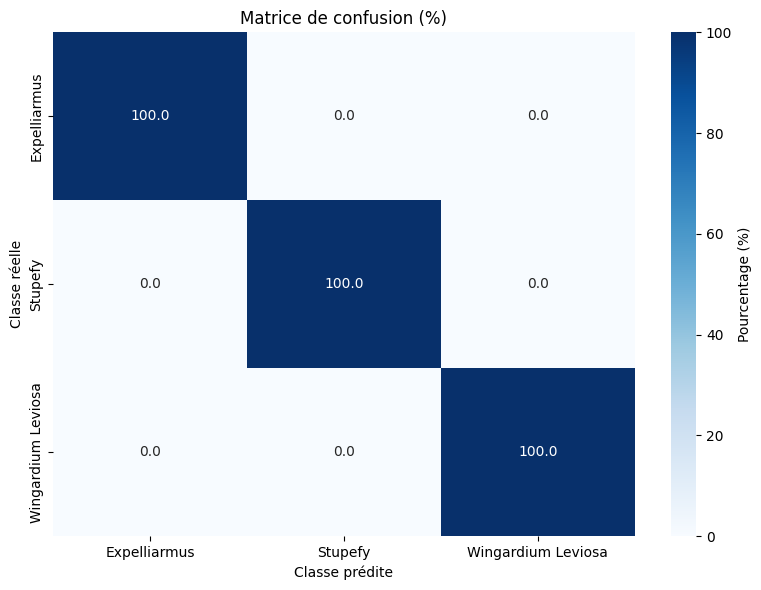

In [131]:
#Matrice de confusion

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def afficher_matrice_confusion(y_true, y_pred, labels):
    """
    Affiche une matrice de confusion normalisée en pourcentage.

    Paramètres
    ----------
    y_true : array
        Labels réels (encodés).
    y_pred : array
        Labels prédits (encodés).
    labels : list
        Liste des noms des classes.
    """

    # Matrice de confusion
    cm = confusion_matrix(y_true, y_pred)

    # Normalisation par ligne (classe réelle)
    cm_percent = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    plt.figure(figsize=(8, 6))

    sns.heatmap(
        cm_percent,
        annot=True,
        fmt=".1f",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels,
        vmin=0,
        vmax=100,
        cbar_kws={"label": "Pourcentage (%)"}
    )

    plt.xlabel("Classe prédite")
    plt.ylabel("Classe réelle")
    plt.title("Matrice de confusion (%)")

    plt.tight_layout()
    plt.show()

afficher_matrice_confusion(
    y_validation_encoded,
    y_validation_pred,
    label_encoder.classes_
)

### e) Questions

1) Decrivez l'architecture du réseau de neurones (le nombre d'entrées/sorties, les différentes couches, les fonctions d'activation...)
2) Faites l'entraînement du modèle avec différentes époques et décrivez les différences observées au niveau des performances.
3) Afficher l'accuracy/fonction de perte de la validation en suivant l'exemple de celles de l'entraînement.
4) Expliquez la signification des métriques affichées.
5) Afficher la matrice de confusion.
6) Calculez l'accuracy du modèle grâce à la matrice de confusion avec epochs=20.
7) Comment obtenir la probabilité de détection et le ratio de faux positifs avec la matrice de confusion?
8) Quel est le rôle de la fonction d'activation ?
9) Pourquoi ajoute-t-on plusieurs couches cachées ?
10) Comment le nombre de neurones influence-t-il la capacité du modèle ?
11) Quel est le rôle du taux d'apprentissage (learning rate) ?

## 8. Test du modèle

Pour cette dernière étape avant le déploiement embarqué sur carte du modèle, nous allons tester le modèle avec les données qu'il n'a jamais vu, les données de test. Ce test permettra d'avoir les performances réelles du modèle quand on lui présente de nouvelles données qui ne lui ont pas servi pour s'entraîner.

### a) Codage et normalisation des features

Ici, avant le test du modèle, il est important de coder et normaliser les caractéristiques pour permettre un test optimal et efficace.

In [132]:
# Données de test

X_test = features_test.drop(
    columns=["source_file", "label"]
)

y_test = features_test["label"]

# Encodage des labels
y_test_encoded = label_encoder.transform(y_test)

# Normalisation des caractéristiques
X_test_scaled = scaler.transform(X_test)

### b) Prédicition du modèle sur les données de test

In [133]:
# Prédictions sur le jeu de test
y_test_proba = model.predict(X_test_scaled)
y_test_pred = np.argmax(y_test_proba, axis=1)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


### c) Performance du modèle

In [134]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
import pandas as pd

# Calcul des métriques
test_metrics = pd.DataFrame({
    "Metric": [
        "Area under ROC Curve",
        "Weighted average Precision",
        "Weighted average Recall",
        "Weighted average F1 score"
    ],
    "Value": [
        roc_auc_score(
            y_test_encoded,
            y_test_proba,
            multi_class="ovr",
            average="weighted"
        ),
        precision_score(
            y_test_encoded,
            y_test_pred,
            average="weighted",
            zero_division=0
        ),
        recall_score(
            y_test_encoded,
            y_test_pred,
            average="weighted",
            zero_division=0
        ),
        f1_score(
            y_test_encoded,
            y_test_pred,
            average="weighted",
            zero_division=0
        )
    ]
})

test_metrics["Value"] = test_metrics["Value"].map(lambda x: f"{x:.2f}")

display(test_metrics.style.hide(axis="index"))

Metric,Value
Area under ROC Curve,1.00
Weighted average Precision,1.00
Weighted average Recall,1.00
Weighted average F1 score,1.00


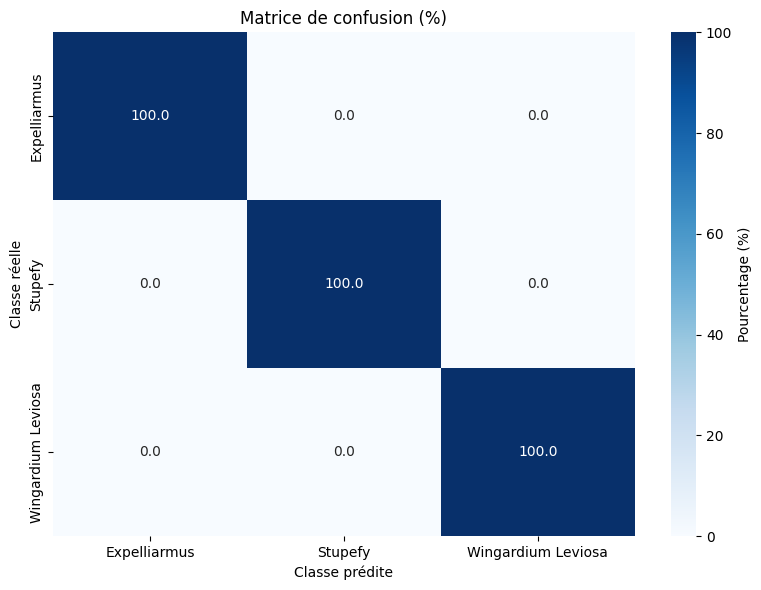

In [135]:
#Matrice de confusion

afficher_matrice_confusion(
    y_test_encoded,
    y_test_pred,
    label_encoder.classes_
)

### d) Questions

1) Quelle est la différence entre les performances de validation (avec les données de validation) et les perfomances de test (avec les données de test)?
2) Afficher la matrice de confusion et les métriques.
3) Analysez la matrice de confusion: comment améliorer la performance du modèle? Sur quels labels faut-il jouer?
4) Pourquoi l'accuracy du test est-elle plus basse que celle de la validation lors de l'entraînement?
5) Que représentent les faux positifs et les faux négatifs ?
6) Pourquoi un modèle peut-il avoir une excellente accuracy mais être peu utile ?
7) Comment détecter un surapprentissage à partir des courbes d'entraînement et de validation ?

## 9. Re-entraînement du modèle (facultatif)

Cette section est facultative, elle est à compiler si il y a de nouvelles acquisitions ou labels ajoutés au dataset de base, ou une quelquonque autre modifications

Features train : (180, 140)
Features validation : (45, 140)
Features test : (75, 140)
Labels : ['Expelliarmus' 'Stupefy' 'Wingardium Leviosa']
Epoch 1/20


C:\Program Files\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.7111 - loss: 0.8277 - val_accuracy: 0.9556 - val_loss: 0.4974
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8944 - loss: 0.4085 - val_accuracy: 0.9556 - val_loss: 0.2495
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9611 - loss: 0.2447 - val_accuracy: 0.9778 - val_loss: 0.1296
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9500 - loss: 0.1733 - val_accuracy: 1.0000 - val_loss: 0.0774
Epoch 5/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9778 - loss: 0.1400 - val_accuracy: 1.0000 - val_loss: 0.0515
Epoch 6/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9889 - loss: 0.0951 - val_accuracy: 1.0000 - val_loss: 0.0365
Epoch 7/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9833 - loss: 0.0908 - val_accuracy: 1.0000 - val_loss: 0.0266
Epoch 8/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9778 - loss: 0.0859 - val_accuracy: 1.0000 - val_loss: 0.0195
Ep

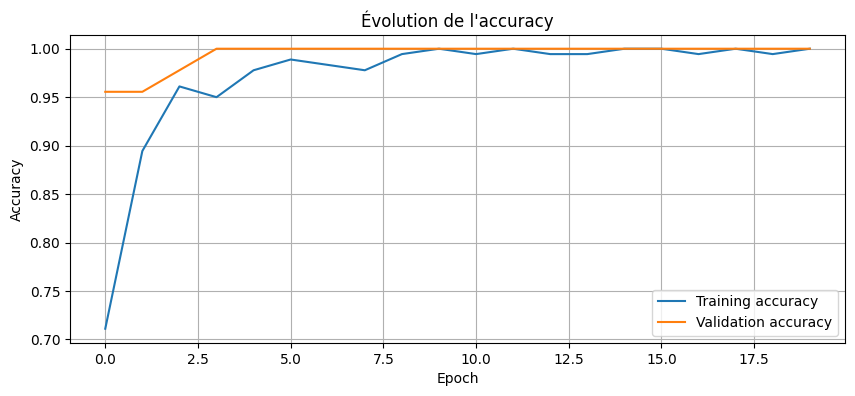

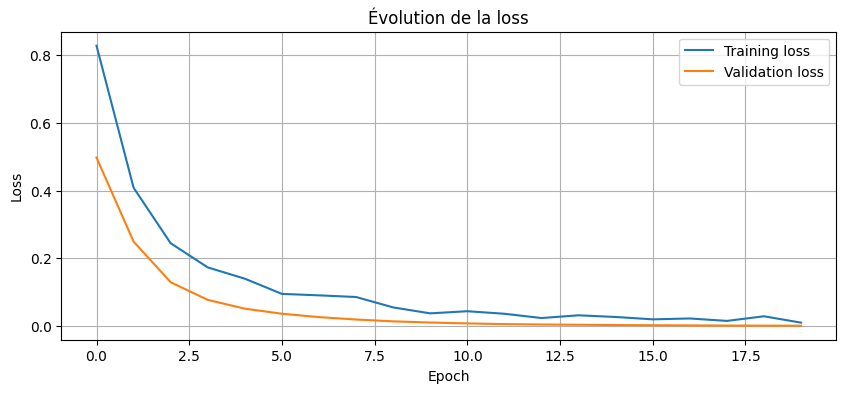

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Métriques - Validation


Metric,Value
Area under ROC Curve,1.00
Weighted average Precision,1.00
Weighted average Recall,1.00
Weighted average F1 score,1.00


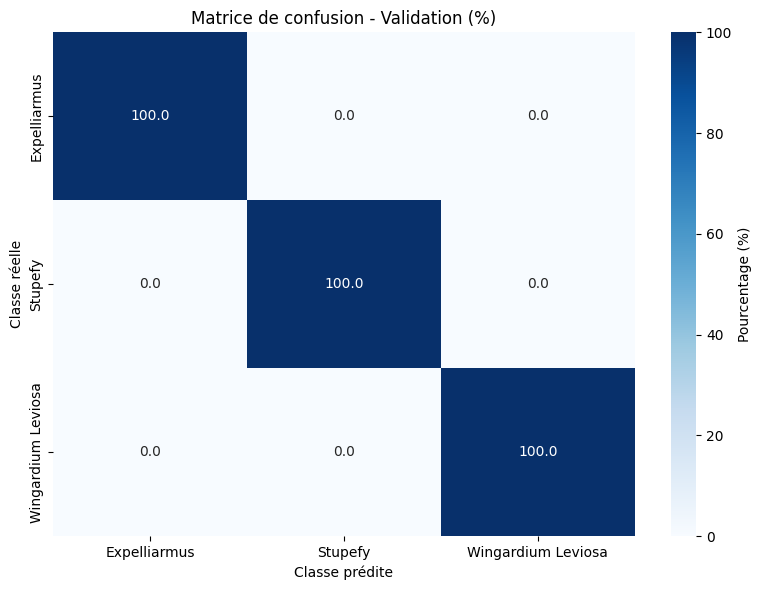

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Métriques - Test


Metric,Value
Area under ROC Curve,1.00
Weighted average Precision,1.00
Weighted average Recall,1.00
Weighted average F1 score,1.00


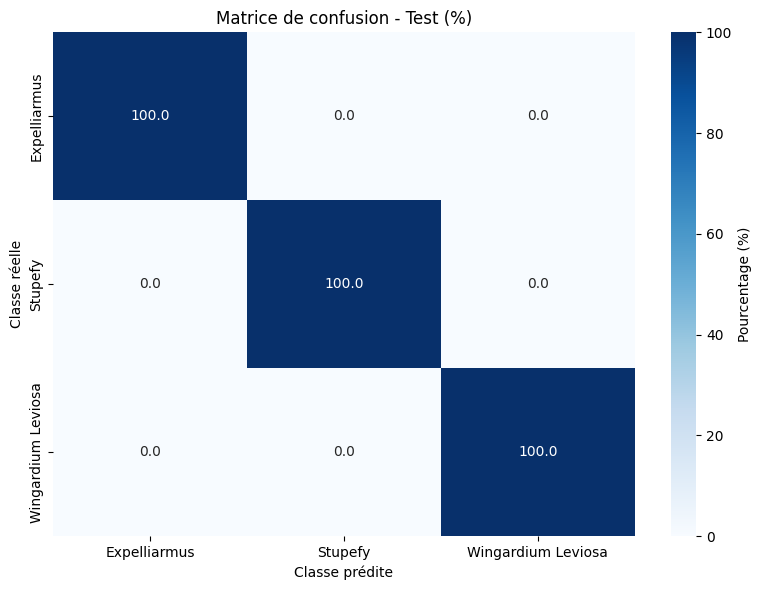

In [136]:
def reentrainer_modele(
    train_data,
    validation_data,
    test_data,
    axes=["AxX", "AxY", "AxZ", "GxX", "GxY", "GxZ"],
    n_fft=20,
    epochs=20,
    batch_size=16
):
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns

    from scipy.stats import skew, kurtosis
    from sklearn.preprocessing import LabelEncoder, StandardScaler
    from sklearn.metrics import (
        precision_score,
        recall_score,
        f1_score,
        roc_auc_score,
        confusion_matrix
    )

    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Dense, Dropout
    from tensorflow.keras.callbacks import EarlyStopping

    def generate_spectral_features(sample):
        features = {}

        for axis in axes:
            signal = sample[axis].to_numpy(dtype=float)
            signal = signal - np.mean(signal)

            features[f"{axis}_rms"] = np.sqrt(np.mean(signal ** 2))
            features[f"{axis}_skewness"] = skew(signal)
            features[f"{axis}_kurtosis"] = kurtosis(signal)

            fft_values = np.fft.rfft(signal)
            power = np.abs(fft_values) ** 2
            power = power[:n_fft]

            for i, value in enumerate(power):
                features[f"{axis}_fft_{i}"] = value

        return features

    def construire_features(dataset):
        feature_rows = []

        for source_file, sample in dataset.groupby("source_file"):
            features = generate_spectral_features(sample)

            features["source_file"] = source_file
            features["label"] = sample["label"].iloc[0]

            feature_rows.append(features)

        return pd.DataFrame(feature_rows)

    def afficher_metriques(y_true, y_pred, y_proba, titre):
        metrics = pd.DataFrame({
            "Metric": [
                "Area under ROC Curve",
                "Weighted average Precision",
                "Weighted average Recall",
                "Weighted average F1 score"
            ],
            "Value": [
                roc_auc_score(
                    y_true,
                    y_proba,
                    multi_class="ovr",
                    average="weighted"
                ),
                precision_score(y_true, y_pred, average="weighted", zero_division=0),
                recall_score(y_true, y_pred, average="weighted", zero_division=0),
                f1_score(y_true, y_pred, average="weighted", zero_division=0)
            ]
        })

        metrics["Value"] = metrics["Value"].map(lambda x: f"{x:.2f}")

        print(titre)
        display(metrics.style.hide(axis="index"))

    def afficher_matrice_confusion(y_true, y_pred, labels, titre):
        cm = confusion_matrix(y_true, y_pred)
        cm_percent = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

        plt.figure(figsize=(8, 6))

        sns.heatmap(
            cm_percent,
            annot=True,
            fmt=".1f",
            cmap="Blues",
            xticklabels=labels,
            yticklabels=labels,
            vmin=0,
            vmax=100,
            cbar_kws={"label": "Pourcentage (%)"}
        )

        plt.title(titre)
        plt.xlabel("Classe prédite")
        plt.ylabel("Classe réelle")
        plt.tight_layout()
        plt.show()

    # --------------------------------------------------------
    # 1. Génération des features
    # --------------------------------------------------------

    features_train = construire_features(train_data)
    features_validation = construire_features(validation_data)
    features_test = construire_features(test_data)

    print("Features train :", features_train.shape)
    print("Features validation :", features_validation.shape)
    print("Features test :", features_test.shape)

    # --------------------------------------------------------
    # 2. Préparation des données
    # --------------------------------------------------------

    X_train = features_train.drop(columns=["source_file", "label"])
    y_train = features_train["label"]

    X_validation = features_validation.drop(columns=["source_file", "label"])
    y_validation = features_validation["label"]

    X_test = features_test.drop(columns=["source_file", "label"])
    y_test = features_test["label"]

    label_encoder = LabelEncoder()

    y_train_encoded = label_encoder.fit_transform(y_train)
    y_validation_encoded = label_encoder.transform(y_validation)
    y_test_encoded = label_encoder.transform(y_test)

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)
    X_validation_scaled = scaler.transform(X_validation)
    X_test_scaled = scaler.transform(X_test)

    print("Labels :", label_encoder.classes_)

    # --------------------------------------------------------
    # 3. Création du modèle
    # --------------------------------------------------------

    model = Sequential([
        Dense(32, activation="relu", input_shape=(X_train_scaled.shape[1],)),
        Dropout(0.2),
        Dense(16, activation="relu"),
        Dropout(0.2),
        Dense(len(label_encoder.classes_), activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    )

    # --------------------------------------------------------
    # 4. Entraînement
    # --------------------------------------------------------

    history = model.fit(
        X_train_scaled,
        y_train_encoded,
        validation_data=(X_validation_scaled, y_validation_encoded),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stop]
    )

    # --------------------------------------------------------
    # 5. Courbes d'entraînement
    # --------------------------------------------------------

    plt.figure(figsize=(10, 4))
    plt.plot(history.history["accuracy"], label="Training accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation accuracy")
    plt.title("Évolution de l'accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(history.history["loss"], label="Training loss")
    plt.plot(history.history["val_loss"], label="Validation loss")
    plt.title("Évolution de la loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    # --------------------------------------------------------
    # 6. Évaluation validation
    # --------------------------------------------------------

    y_validation_proba = model.predict(X_validation_scaled)
    y_validation_pred = np.argmax(y_validation_proba, axis=1)

    afficher_metriques(
        y_validation_encoded,
        y_validation_pred,
        y_validation_proba,
        "Métriques - Validation"
    )

    afficher_matrice_confusion(
        y_validation_encoded,
        y_validation_pred,
        label_encoder.classes_,
        "Matrice de confusion - Validation (%)"
    )

    # --------------------------------------------------------
    # 7. Évaluation test
    # --------------------------------------------------------

    y_test_proba = model.predict(X_test_scaled)
    y_test_pred = np.argmax(y_test_proba, axis=1)

    afficher_metriques(
        y_test_encoded,
        y_test_pred,
        y_test_proba,
        "Métriques - Test"
    )

    afficher_matrice_confusion(
        y_test_encoded,
        y_test_pred,
        label_encoder.classes_,
        "Matrice de confusion - Test (%)"
    )

    return {
        "model": model,
        "history": history,
        "scaler": scaler,
        "label_encoder": label_encoder,
        "features_train": features_train,
        "features_validation": features_validation,
        "features_test": features_test,
        "X_train_scaled": X_train_scaled,
        "X_validation_scaled": X_validation_scaled,
        "X_test_scaled": X_test_scaled,
        "y_train_encoded": y_train_encoded,
        "y_validation_encoded": y_validation_encoded,
        "y_test_encoded": y_test_encoded
    }

resultats = reentrainer_modele(
    train_data,
    validation_data,
    test_data,
    n_fft=20,
    epochs=20,
    batch_size=16
)

model = resultats["model"]
scaler = resultats["scaler"]
label_encoder = resultats["label_encoder"]

## 10. Déploiement du modèle sur la carte Seeed Xiao NRF52840 sense

Nous arrivons maintenant à la dernière étape, celle qui nous permettra de reconnaître tous les sorts que l'on pourrait lancer en tant que sorciers !
Ici, on va charger notre modèle sur la carte Seeed Xiao NRF52840. 
* Mais comment faire en sorte que la carte nous montre les moments d'acquisition en direct et les resultats des prédicitions du modèle?

Pour cela, nous allons utiliser la LED présente sur la carte: celle-ci va rester allumée en continue pendant toute la durée de l'acquisition. Puis, elle va clignoter un certain nombre de fois selon le résultat prédit (par exemple, si elle détecte "Expelliarmus", elle va clignoter une fois, si elle détecte "Stupefy", elle va clignoter 2 fois...)

Une fois le modèle uploadé sur la carte, débranchez la carte de l'ordinateur et activez l'alimentation de la carte pour avoir le modèle embarqué. 

In [137]:
# ============================================================
# Déploiement TFLite pour Seeed XIAO nRF52840 Sense
# Génération automatique de modele_sort.h et scaler_params.h
# ============================================================

import tensorflow as tf
import json
import os

# Récupération des éléments du modèle entraîné
model = resultats["model"]
scaler = resultats["scaler"]
label_encoder = resultats["label_encoder"]

labels = list(label_encoder.classes_)

# ------------------------------------------------------------
# 1. Conversion du modèle Keras en TensorFlow Lite
# ------------------------------------------------------------

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_model = converter.convert()

with open("modele_sort.tflite", "wb") as f:
    f.write(tflite_model)

print("Modèle TFLite généré : modele_sort.tflite")
print("Taille du modèle :", len(tflite_model), "octets")


# ------------------------------------------------------------
# 2. Génération du fichier modele_sort.h
# ------------------------------------------------------------

with open("modele_sort.h", "w") as f:
    f.write("#ifndef MODELE_SORT_H\n")
    f.write("#define MODELE_SORT_H\n\n")

    f.write("const unsigned char modele_sort[] = {\n")

    for i, byte in enumerate(tflite_model):
        if i % 12 == 0:
            f.write("  ")
        f.write(f"0x{byte:02x}, ")
        if i % 12 == 11:
            f.write("\n")

    f.write("\n};\n\n")
    f.write(f"const unsigned int modele_sort_len = {len(tflite_model)};\n\n")
    f.write("#endif\n")

print("Fichier généré : modele_sort.h")


# ------------------------------------------------------------
# 3. Génération du fichier scaler_params.h
# ------------------------------------------------------------

mean = scaler.mean_
scale = scaler.scale_

with open("scaler_params.h", "w") as f:
    f.write("#ifndef SCALER_PARAMS_H\n")
    f.write("#define SCALER_PARAMS_H\n\n")

    f.write(f"#define N_FEATURES {len(mean)}\n")
    f.write(f"#define N_CLASSES {len(labels)}\n\n")

    f.write("const float scaler_mean[N_FEATURES] = {\n")
    f.write(", ".join([f"{x:.8f}f" for x in mean]))
    f.write("\n};\n\n")

    f.write("const float scaler_scale[N_FEATURES] = {\n")
    f.write(", ".join([f"{x:.8f}f" for x in scale]))
    f.write("\n};\n\n")

    f.write("const char* labels[N_CLASSES] = {\n")
    f.write(", ".join([f'"{label}"' for label in labels]))
    f.write("\n};\n\n")

    f.write("#endif\n")

print("Fichier généré : scaler_params.h")


INFO:tensorflow:Assets written to: C:\Users\BASSAN~1\AppData\Local\Temp\tmpzhsogop0\assets


INFO:tensorflow:Assets written to: C:\Users\BASSAN~1\AppData\Local\Temp\tmpzhsogop0\assets


Saved artifact at 'C:\Users\BASSAN~1\AppData\Local\Temp\tmpzhsogop0'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 138), dtype=tf.float32, name='keras_tensor_30')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  2256607603856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2256607603088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2256607605584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2256607602896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2256607593680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2256607596176: TensorSpec(shape=(), dtype=tf.resource, name=None)
Modèle TFLite généré : modele_sort.tflite
Taille du modèle : 9592 octets
Fichier généré : modele_sort.h
Fichier généré : scaler_params.h


In [138]:
!pip install pyserial

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [139]:
# ============================================================
# Déploiement complet XIAO + FFT + Serial Monitor depuis Jupyter
# ============================================================

import os, time, subprocess, serial, shutil, sys

PORT = "COM9"
BAUDRATE = 115200

SKETCH_NAME = "deploiement_xiao_fft"
SKETCH_DIR = r"C:\temp\deploiement_xiao_fft"

os.makedirs(SKETCH_DIR, exist_ok=True)

ino_path = os.path.join(SKETCH_DIR, SKETCH_NAME + ".ino")

FQBN = "Seeeduino:nrf52:xiaonRF52840Sense"
ARDUINO_CLI = r"U:\Stage IA\arduino-cli.exe"

arduino_code = r'''
#include <Chirale_TensorFlowLite.h>
#include "tensorflow/lite/micro/all_ops_resolver.h"
#include "tensorflow/lite/micro/micro_interpreter.h"
#include "tensorflow/lite/schema/schema_generated.h"

#include "LSM6DS3.h"
#include "Wire.h"
#include "modele_sort.h"
#include "scaler_params.h"

LSM6DS3 imu(I2C_MODE, 0x6A);

#define SAMPLE_RATE_HZ 50
#define WINDOW_SECONDS 2
#define N_SAMPLES 100
#define N_AXES 6
#define N_FFT 20

float buffer_data[N_SAMPLES][N_AXES];
float features[N_FEATURES];

constexpr int tensor_arena_size = 50 * 1024;
uint8_t tensor_arena[tensor_arena_size];

const tflite::Model* tflite_model;
tflite::MicroInterpreter* interpreter;
TfLiteTensor* input;
TfLiteTensor* output;
tflite::AllOpsResolver resolver;

void setup() {
  Serial.begin(115200);
  while (!Serial);

  pinMode(LED_BUILTIN, OUTPUT);
  digitalWrite(LED_BUILTIN, HIGH);

  if (imu.begin() != 0) {
    Serial.println("Erreur IMU");
    while (1);
  }

  tflite_model = tflite::GetModel(modele_sort);

  static tflite::MicroInterpreter static_interpreter(
    tflite_model,
    resolver,
    tensor_arena,
    tensor_arena_size
  );

  interpreter = &static_interpreter;

  if (interpreter->AllocateTensors() != kTfLiteOk) {
    Serial.println("Erreur allocation tenseurs");
    while (1);
  }

  input = interpreter->input(0);
  output = interpreter->output(0);

  Serial.println("XIAO prête.");
}

void loop() {
  Serial.println("Prépare le geste...");
  delay(1000);

  digitalWrite(LED_BUILTIN, LOW);
  enregistrer_fenetre();
  digitalWrite(LED_BUILTIN, HIGH);

  calculer_features();
  normaliser_features();

  for (int i = 0; i < N_FEATURES; i++) {
    input->data.f[i] = features[i];
  }

  if (interpreter->Invoke() != kTfLiteOk) {
    Serial.println("Erreur inference");
    return;
  }

  afficher_prediction();
  delay(2000);
}

void enregistrer_fenetre() {
  for (int i = 0; i < N_SAMPLES; i++) {
    buffer_data[i][0] = imu.readFloatAccelX();
    buffer_data[i][1] = imu.readFloatAccelY();
    buffer_data[i][2] = imu.readFloatAccelZ();
    buffer_data[i][3] = imu.readFloatGyroX();
    buffer_data[i][4] = imu.readFloatGyroY();
    buffer_data[i][5] = imu.readFloatGyroZ();

    delay(1000 / SAMPLE_RATE_HZ);
  }
}

float moyenne_axe(int axe) {
  float somme = 0;
  for (int i = 0; i < N_SAMPLES; i++) somme += buffer_data[i][axe];
  return somme / N_SAMPLES;
}

float rms_axe(int axe, float mean) {
  float somme = 0;
  for (int i = 0; i < N_SAMPLES; i++) {
    float x = buffer_data[i][axe] - mean;
    somme += x * x;
  }
  return sqrt(somme / N_SAMPLES);
}

float skewness_axe(int axe, float mean) {
  float m2 = 0;
  float m3 = 0;

  for (int i = 0; i < N_SAMPLES; i++) {
    float x = buffer_data[i][axe] - mean;
    m2 += x * x;
    m3 += x * x * x;
  }

  m2 /= N_SAMPLES;
  m3 /= N_SAMPLES;

  if (m2 == 0) return 0;
  return m3 / pow(m2, 1.5);
}

float kurtosis_axe(int axe, float mean) {
  float m2 = 0;
  float m4 = 0;

  for (int i = 0; i < N_SAMPLES; i++) {
    float x = buffer_data[i][axe] - mean;
    m2 += x * x;
    m4 += x * x * x * x;
  }

  m2 /= N_SAMPLES;
  m4 /= N_SAMPLES;

  if (m2 == 0) return 0;
  return (m4 / (m2 * m2)) - 3.0;
}

float puissance_fft(int axe, int k, float mean) {
  float real = 0;
  float imag = 0;

  for (int n = 0; n < N_SAMPLES; n++) {
    float x = buffer_data[n][axe] - mean;
    float angle = -2.0 * PI * k * n / N_SAMPLES;

    real += x * cos(angle);
    imag += x * sin(angle);
  }

  return real * real + imag * imag;
}

void calculer_features() {
  int index = 0;

  for (int axe = 0; axe < N_AXES; axe++) {
    float mean = moyenne_axe(axe);

    features[index++] = rms_axe(axe, mean);
    features[index++] = skewness_axe(axe, mean);
    features[index++] = kurtosis_axe(axe, mean);

    for (int k = 0; k < N_FFT; k++) {
      features[index++] = puissance_fft(axe, k, mean);
    }
  }
}

void normaliser_features() {
  for (int i = 0; i < N_FEATURES; i++) {
    features[i] = (features[i] - scaler_mean[i]) / scaler_scale[i];
  }
}

void clignoter_led(int nombre) {
  for (int i = 0; i < nombre; i++) {
    digitalWrite(LED_BUILTIN, LOW);
    delay(250);
    digitalWrite(LED_BUILTIN, HIGH);
    delay(250);
  }
}

void afficher_prediction() {
  int best_index = 0;
  float best_score = output->data.f[0];

  for (int i = 1; i < N_CLASSES; i++) {
    if (output->data.f[i] > best_score) {
      best_score = output->data.f[i];
      best_index = i;
    }
  }

  Serial.print("Sort reconnu : ");
  Serial.print(labels[best_index]);
  Serial.print(" | Score : ");
  Serial.println(best_score, 4);

  clignoter_led(best_index + 1);
}
'''

# Copie des fichiers générés précédemment
for filename in ["modele_sort.h", "scaler_params.h"]:
    src = filename
    dst = os.path.join(SKETCH_DIR, filename)
    if os.path.exists(src):
        with open(src, "r", encoding="utf-8", errors="ignore") as f:
            content = f.read()
        with open(dst, "w", encoding="utf-8") as f:
            f.write(content)
    else:
        print(f"Fichier manquant : {filename}")


with open(ino_path, "w", encoding="utf-8") as f:
    f.write(arduino_code)

print("Sketch généré :", ino_path)

# Compilation et téléversement via Arduino CLI
try:
    print("Compilation...")
    compile_result = subprocess.run(
        [ARDUINO_CLI, "compile", "--fqbn", FQBN, SKETCH_DIR],
        capture_output=True,
        text=True
    )

    print(compile_result.stdout)
    print(compile_result.stderr)

    if compile_result.returncode != 0:
      raise SystemExit("Erreur compilation : arrêt avant Serial Monitor")

    upload_result = subprocess.run(
        [ARDUINO_CLI, "upload", "-p", PORT, "--fqbn", FQBN, SKETCH_DIR],
        capture_output=True,
        text=True
    )

    print(upload_result.stdout)
    print(upload_result.stderr)

    if upload_result.returncode != 0:
      raise SystemExit("Erreur téléversement : arrêt avant Serial Monitor")

    print("Téléversement terminé.")

except FileNotFoundError:
    print("arduino-cli n'est pas installé ou pas dans le PATH.")
    print("Le sketch est généré, mais le notebook ne peut pas compiler/téléverser automatiquement.")

except subprocess.CalledProcessError as e:
    print("Erreur pendant la compilation ou le téléversement.")
    print("Code erreur :", e.returncode)


# Serial Monitor dans Jupyter
print("\nOuverture du Serial Monitor Jupyter...")
print("Arrête la cellule pour quitter.\n")

try:
    ser = serial.Serial(PORT, BAUDRATE, timeout=1)
    time.sleep(2)

    while True:
        ligne = ser.readline().decode("utf-8", errors="ignore").strip()
        if ligne:
            print(ligne)

except KeyboardInterrupt:
    print("Serial Monitor arrêté.")

finally:
    try:
        ser.close()
    except:
        pass

Sketch généré : C:\temp\deploiement_xiao_fft\deploiement_xiao_fft.ino
Compilation...
ATTENTION: la bibliothÃ¨que Chirale_TensorFLowLite prÃ©tend Ãªtre exÃ©cutable sur la (ou les) architecture(s) mbed_nano, esp32, mbed_nicla, mbed_portenta, mbed_giga et peut Ãªtre incompatible avec votre carte actuelle qui s'exÃ©cute sur nrf52.

Used library             Version Path
Chirale_TensorFLowLite   2.0.0   C:\Users\bassant-koum\Documents\Arduino\libraries\Chirale_TensorFlowLite
Wire                     1.0     C:\Users\bassant-koum\AppData\Local\Arduino15\packages\Seeeduino\hardware\nrf52\1.1.13\libraries\Wire
Seeed Arduino LSM6DS3    2.0.6   C:\Users\bassant-koum\Documents\Arduino\libraries\Seeed_Arduino_LSM6DS3
Adafruit TinyUSB Library 1.7.0   C:\Users\bassant-koum\AppData\Local\Arduino15\packages\Seeeduino\hardware\nrf52\1.1.13\libraries\Adafruit_TinyUSB_Arduino
SPI                      1.0     C:\Users\bassant-koum\AppData\Local\Arduino15\packages\Seeeduino\hardware\nrf52\1.1.13\libraries\S

SystemExit: Erreur compilation : arrêt avant Serial Monitor

C:\Program Files\Python312\Lib\site-packages\IPython\core\interactiveshell.py:3756: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


### b) Questions

1) Expliquez pourquoi on parle de modèle "embarqué".
2) Donnez un autre exemple de modèle embarqué qui ressemble à celui que l'on vient de créer, en expliquant qualitativement comment il fonctionne(rait).
3) Pourquoi cherche-t-on à réduire la taille d'un modèle destiné à être embarqué ?
4) Quelles contraintes matérielles rencontre-t-on sur un système embarqué ?
5) Pourquoi la vitesse d'inférence est-elle importante dans un système embarqué ?
6) Quels compromis peut-on faire entre précision et temps de calcul ?
7) Pourquoi les données disponibles lors du déploiement doivent-elles être similaires aux données d'entraînement ?